In [67]:
import os
os.chdir("/Users/srujansingh/Documents/JeanFan_Lab/Kidney_Structural_Analysis/")

In [68]:
import scanpy as sc
ctrl1_data = sc.read_h5ad("data/2um/Ctrl_1A2/Ctrl_1A2_visiumhd_2um_proximal_labeled.h5ad")

AnnData object is a standardized data structure used in SC and ST datasets that hold all information at one pleace like:

Observations (obs) → cells / spots / pixels

Variables (var) → genes

Matrix (X) → expression values (genes × cells/spots)

Extra metadata → spatial coordinates, annotations, embeddings, etc.


In [69]:
#Visualizing the AnnData structure:
ctrl1_data

AnnData object with n_obs × n_vars = 5549563 × 19059
    obs: 'in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres', 'pxl_col_in_fullres', 'proximal_tubule_geojson_feature_index'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial'

The ctr1_data AnnData object contaisn 19059 genes (features) x 5549563 bins (spatial units).

In [70]:
#Visualizing the observations:
ctrl1_data.obs.head()

,in_tissue,array_row,array_col,pxl_row_in_fullres,pxl_col_in_fullres,proximal_tubule_geojson_feature_index
s_002um_00000_02609-1,1,0,2609,1164.609932,6249.759373,<NA>
s_002um_00000_02610-1,1,0,2610,1164.662587,6245.220638,<NA>
s_002um_00000_02611-1,1,0,2611,1164.715242,6240.681902,<NA>
s_002um_00000_02612-1,1,0,2612,1164.767897,6236.143167,<NA>
s_002um_00000_02613-1,1,0,2613,1164.820552,6231.604433,<NA>


In [71]:
#Visualizing the features:
ctrl1_data.var.head()

,gene_ids,feature_types,genome
Xkr4,ENSMUSG00000051951,Gene Expression,mm10
Rp1,ENSMUSG00000025900,Gene Expression,mm10
Sox17,ENSMUSG00000025902,Gene Expression,mm10
Lypla1,ENSMUSG00000025903,Gene Expression,mm10
Tcea1,ENSMUSG00000033813,Gene Expression,mm10


In [72]:
#Visualizing the features:
ctrl1_data.obsm

AxisArrays with keys: spatial

In [73]:
ctrl1_data.obs["proximal_tubule_geojson_feature_index"].unique()

<IntegerArray>
[<NA>,  929,  145, 2875, 5680, 2409, 2683,   86, 4813,  509,
 ...
 2607, 1603, 4799, 1242, 2392, 3531, 6605, 5953, 1777, 5938]
Length: 1598, dtype: Int64

1.BRUSH BORDER (APICAL MARKERS)

A.Transporters / channels<br>

Slc34a1 – sodium-phosphate cotransporter (classic proximal tubule marker) <br>
Slc5a2 – SGLT2 (glucose reabsorption, very apical)<br>
Slc9a3 – NHE3 (Na⁺/H⁺ exchanger, strongly apical)<br>
Aqp1 – aquaporin-1 (proximal tubule water transport, apical + membrane-wide)<br>

B.Brush border structural / membrane proteins<br>

Vil1 – villin (microvilli actin bundling; strong brush border marker)<br>
Dpp4 – dipeptidyl peptidase 4 (apical membrane enzyme)<br>

2.BASOLATERAL PROXIMAL TUBULE MARKERS:
A.Ion transport / pumps<br>

Atp1a1 – Na⁺/K⁺ ATPase α1 (canonical basolateral pump)<br>
Atp1b1 – Na⁺/K⁺ ATPase β1 subunit<br>
Slc4a4 – NBCe1 (bicarbonate transporter, basolateral acid-base handling)<br>

B.Metabolite / ion exchange<br>

Slc2a1 – GLUT1 (often basolateral glucose transport in certain PT segments)<br>
Slc7a7 – amino acid transport (basolateral exchange roles)


In [74]:
select_genes = ["Slc34a1", "Slc5a2","Slc9a3","Aqp1","Vil1","Dpp4", "Atp1a1","Atp1b1","Slc4a4","Slc2a1","Slc7a7"]
[g in ctrl1_data.var_names for g in select_genes]

[True, True, True, True, True, True, True, True, True, True, True]

In [75]:
#Subsettig the Ctrl1A2 dataset only to a few apical and basal marker genes:
slc=ctrl1_data[:,select_genes]
ctrl_poles=slc.to_df()
ctrl_poles.head()

,Slc34a1,Slc5a2,Slc9a3,Aqp1,Vil1,Dpp4,Atp1a1,Atp1b1,Slc4a4,Slc2a1,Slc7a7
s_002um_00000_02609-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
s_002um_00000_02610-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
s_002um_00000_02611-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
s_002um_00000_02612-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
s_002um_00000_02613-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [76]:
ctrl_poles

,Slc34a1,Slc5a2,Slc9a3,Aqp1,Vil1,Dpp4,Atp1a1,Atp1b1,Slc4a4,Slc2a1,Slc7a7
s_002um_00000_02609-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
s_002um_00000_02610-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
s_002um_00000_02611-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
s_002um_00000_02612-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
s_002um_00000_02613-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
s_002um_03347_00386-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
s_002um_03347_00387-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
s_002um_03347_00388-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
s_002um_03347_00389-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [77]:
ctrl1_data.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 69118754 stored elements and shape (5549563, 19059)>

In [78]:
#Performing row wise sums on the ra counts matrix:
#Rows (i) are 2um bin IDs and columns (j) are genes:
bin_counts = ctrl1_data.X.sum(axis=1).A1 #.A1 converts the 2D array into a flat vector.
bin_counts.shape

(5549563,)

In [79]:
#Extracting the coordinates of the 
coords = ctrl1_data.obsm["spatial"]
coords.shape

(5549563, 2)

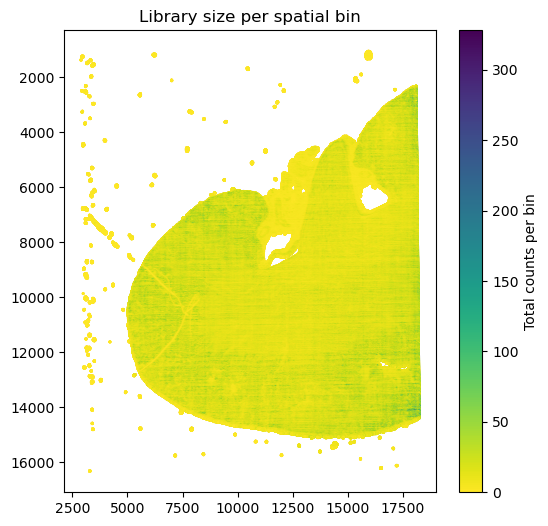

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(coords[:,0], coords[:,1],
            c=bin_counts,
            s=1,
            cmap="viridis_r") #viridis_r for reverse color map
plt.colorbar(label="Total counts per bin")
plt.gca().invert_yaxis()
plt.title("Library size per spatial bin")
plt.show()

In [65]:
ctrl1_data.obs['proximal_tubule_geojson_feature_index'].isna().sum() #To check how many bins are NaN (not assigned to any proximal tubules)
ctrl1_data_PT = ctrl1_data[~ctrl1_data.obs['proximal_tubule_geojson_feature_index'].isna()].copy()
ctrl1_data_PT.shape #to check the dimensions of the subset matrix
ctrl1_data_PT.obs.head()

,in_tissue,array_row,array_col,pxl_row_in_fullres,pxl_col_in_fullres,proximal_tubule_geojson_feature_index
s_002um_00304_00021-1,1,304,21,2407.153091,18011.820723,929
s_002um_00304_00022-1,1,304,22,2407.205739,18007.281833,929
s_002um_00304_00023-1,1,304,23,2407.258388,18002.742943,929
s_002um_00304_00024-1,1,304,24,2407.311036,17998.204053,929
s_002um_00304_00025-1,1,304,25,2407.363684,17993.665163,929


In [66]:
ctrl1_data_PT[:,select_genes].to_df().head()

,Slc34a1,Slc5a2,Slc9a3,Aqp1,Vil1,Dpp4,Atp1a1,Atp1b1,Slc4a4,Slc2a1,Slc7a7
s_002um_00304_00021-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
s_002um_00304_00022-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
s_002um_00304_00023-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
s_002um_00304_00024-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
s_002um_00304_00025-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
ctrl1_data_PT.obsm["spatial"] #To get the coordinates of the subset gene.

array([[18011.82  ,  2407.153 ],
       [18007.281 ,  2407.2058],
       [18002.742 ,  2407.2583],
       ...,
       [14033.221 , 15050.599 ],
       [14028.682 , 15050.65  ],
       [14024.143 , 15050.703 ]], shape=(881056, 2), dtype=float32)